### Deep Learning Evaluationm methods

### 1. Binary classification on breast cancer dataset 

In [2]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


data = load_breast_cancer()


X = data.data
y = data.target

print(f'Dataset shape {X.shape}')


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state = 43)

# Scaling data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Dataset shape (569, 30)


### Creating a neural network

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

import tensorflow as tf

# in keras there is no implementation of specificity
def specificity(y_true, y_pred):
    
    y_pred = tf.cast(y_pred, tf.float32)
    y_true = tf.cast(y_true, tf.float32)

    y_pred_pos = tf.round(tf.clip_by_value(y_pred, 0.0, 1.0))
    y_pred_neg = 1.0 - y_pred_pos

    y_true_pos = tf.round(tf.clip_by_value(y_true, 0.0, 1.0))
    y_true_neg = 1.0 - y_true_pos

    
    tn = tf.reduce_sum(y_true_neg * y_pred_neg)
    fp = tf.reduce_sum(y_true_neg * y_pred_pos)

    
    return tn / (tn + fp + 1e-7)

# model 
model = Sequential(
    [
    Dense(16, activation = "relu", input_shape = (X_train.shape[1],)),
    Dense(8, activation = "relu"),
    Dense(1, activation = 'sigmoid'),
    ]
)



model.compile(optimizer = 'adam', loss = 'binary_crossentropy', 
              metrics = ['accuracy',tf.keras.metrics.Recall(),
        tf.keras.metrics.Precision(), specificity,],)

# Training model on 15 epochs
history = model.fit(X_train, y_train, epochs = 15, batch_size = 16, validation_split = 0.1)


# Evaluation
loss, accuracy, recall, precision, spc = model.evaluate(X_test, y_test)
print(f"\ Accuracy on test dataset  {accuracy * 100:.2f}%")
print(f"\Recall on test dataset  Czułość na zbiorze testowym: {recall * 100:.2f}%")
print(f"\Precision on test dataset : {precision * 100:.2f}%")
print(f"\Specificity on test dataset : {spc * 100:.2f}%")




Epoch 1/15


<>:47: SyntaxWarning: invalid escape sequence '\ '
<>:48: SyntaxWarning: invalid escape sequence '\R'
<>:49: SyntaxWarning: invalid escape sequence '\P'
<>:50: SyntaxWarning: invalid escape sequence '\S'
<>:47: SyntaxWarning: invalid escape sequence '\ '
<>:48: SyntaxWarning: invalid escape sequence '\R'
<>:49: SyntaxWarning: invalid escape sequence '\P'
<>:50: SyntaxWarning: invalid escape sequence '\S'
C:\Users\maksp\AppData\Local\Temp\ipykernel_15268\2429294656.py:47: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Accuracy on test dataset  {accuracy * 100:.2f}%")
C:\Users\maksp\AppData\Local\Temp\ipykernel_15268\2429294656.py:48: SyntaxWarning: invalid escape sequence '\R'
  print(f"\Recall on test dataset  Czułość na zbiorze testowym: {recall * 100:.2f}%")
C:\Users\maksp\AppData\Local\Temp\ipykernel_15268\2429294656.py:49: SyntaxWarning: invalid escape sequence '\P'
  print(f"\Precision on test dataset : {precision * 100:.2f}%")
C:\Users\maksp\AppData\Local\Temp\ipykernel_

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4352 - loss: 0.6785 - precision_1: 0.9259 - recall_1: 0.0984 - specificity: 0.9295 - val_accuracy: 0.5652 - val_loss: 0.6433 - val_precision_1: 0.7857 - val_recall_1: 0.3929 - val_specificity: 0.6905
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8068 - loss: 0.5560 - precision_1: 0.9888 - recall_1: 0.6969 - specificity: 0.5604 - val_accuracy: 0.8261 - val_loss: 0.5726 - val_precision_1: 0.8846 - val_recall_1: 0.8214 - val_specificity: 0.4345
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9193 - loss: 0.4789 - precision_1: 0.9825 - recall_1: 0.8858 - specificity: 0.4383 - val_accuracy: 0.8043 - val_loss: 0.5000 - val_precision_1: 0.8519 - val_recall_1: 0.8214 - val_specificity: 0.4137
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9413 - loss: 0.3804 - precision_1: 0.9713 - recall_1: 0.9331 - specificity: 0.4041 - val_accuracy: 0.8261 - val_loss: 0.3932 - val_precision_1: 0.8571 - v

### Confusion matrix

In [6]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred_probs = model.predict(X_test)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Creating a confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_classes).ravel()


true_specificity = tn / (tn + fp)

print("Summary")
print(f"Specificity: {true_specificity * 100:.2f}%")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")

# 4. Wyświetlamy pełny, profesjonalny raport
print("\nClass raport:")
print(classification_report(y_test, y_pred_classes, target_names=['Złośliwy (0)', 'Łagodny (1)']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Summary
Specificity: 94.87%
True Negatives (TN): 37
False Positives (FP): 2

Class raport:
              precision    recall  f1-score   support

Złośliwy (0)       0.95      0.95      0.95        39
 Łagodny (1)       0.97      0.97      0.97        75

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



### Iris Data Set

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Loading Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state = 43)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)





In [ ]:
#model 
model = Sequential(
    [
    Dense(16, activation = "relu", input_shape = (X_train.shape[1],)),
    Dense(8, activation = "relu"),
    Dense(1, activation = 'sigmoid'),
    ]
)

model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', 
              metrics = ['accuracy',tf.keras.metrics.Recall(),
        tf.keras.metrics.Precision(),],)

history = model.fit(X_train, y_train, epochs = 20, batch_size = 16, validation_split = 0.1)

# Ewaluacja

loss, accuracy, recall, precision = model.evaluate(X_test, y_test)

print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'Precision: {precision}')



Epoch 1/20


C:\Users\Maks\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.2037 - loss: 0.0000e+00 - precision_1: 0.3043 - recall_1: 0.0933 - val_accuracy: 0.5833 - val_loss: 0.0000e+00 - val_precision_1: 1.0000 - val_recall_1: 0.3750
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3611 - loss: 0.0000e+00 - precision_1: 0.8500 - recall_1: 0.2267 - val_accuracy: 0.6667 - val_loss: 0.0000e+00 - val_precision_1: 1.0000 - val_recall_1: 0.5000
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4352 - loss: 0.0000e+00 - precision_1: 1.0000 - recall_1: 0.3867 - val_accuracy: 0.6667 - val_loss: 0.0000e+00 - val_precision_1: 1.0000 - val_recall_1: 0.5000
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4630 - loss: 0.0000e+00 - precision_1: 1.0000 - recall_1: 0.4933 - val_accuracy: 0.6667 - val_loss: 0.0000e+00 - val_precision_1: 1.0000 - val_recall_1: 0.5000
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4907 - loss: 0.0000e+00 - precision_1: 1.0000 - recall_1

### Krzywa uczenia

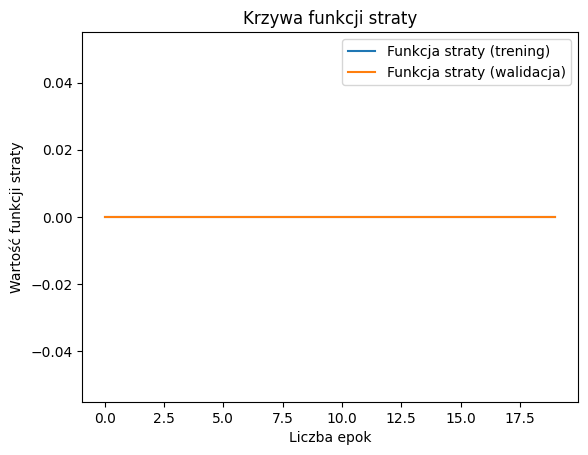

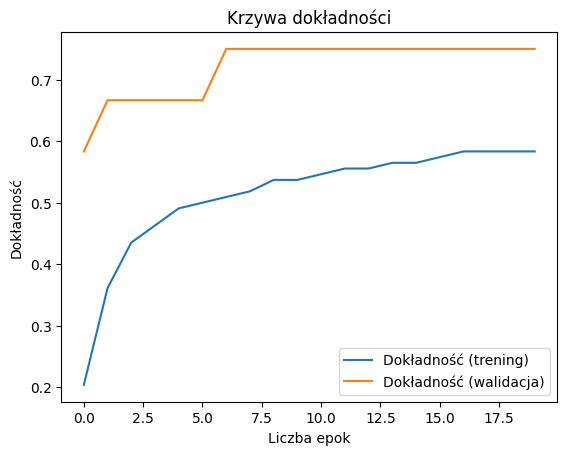

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Funkcja straty (trening)')
plt.plot(history.history['val_loss'], label='Funkcja straty (walidacja)')
plt.xlabel('Liczba epok')
plt.ylabel('Wartość funkcji straty')
plt.legend()
plt.title('Krzywa funkcji straty')
plt.show()
plt.plot(history.history['accuracy'], label='Dokładność (trening)')
plt.plot(history.history['val_accuracy'], label='Dokładność (walidacja)')
plt.xlabel('Liczba epok')
plt.ylabel('Dokładność')
plt.legend()
plt.title('Krzywa dokładności')
plt.show()

### Zadanie z transferem wcześniej nauczonego modele + wczytanie danych VGGFace

### Wczytywanie danych z plików


In [20]:
import os
import tensorflow as tf
path_train = 'A:/github/BigDataLabs/Data/train'
wybrane_osoby = os.listdir(path_train)[:5]

print(wybrane_osoby)

# otwieramy foldery ktore sa w liscie wybrane osoby
train_ds = tf.keras.utils.image_dataset_from_directory(
    path_train,
    validation_split = 0.2,
    subset = 'training',
    seed = 123,
    image_size = (224,224),
    batch_size = 32,
    label_mode = 'categorical',
    class_names = wybrane_osoby
)
# plikow jest niby malo ale bedziemy uzywac modelu, ktory juz zostal wczesniej wytrenowany

test_ds = tf.keras.utils.image_dataset_from_directory(
    path_train,
    validation_split = 0.2,
    subset = 'validation',
    seed = 123,
    image_size = (224,224),
    batch_size = 32,
    label_mode = 'categorical',
    class_names = wybrane_osoby,
    #shuffle = False
)

# musimy dodać warstwe normalizacji

normalization_layer = tf.keras.layers.Rescaling(1./255)


train_ds = train_ds.map(lambda  x, y : (normalization_layer(x), y) ) 
test_ds = test_ds.map(lambda  x, y : (normalization_layer(x), y) ) 





['n000002', 'n000003', 'n000004', 'n000005', 'n000006']
Found 1621 files belonging to 5 classes.
Using 1297 files for training.
Found 1621 files belonging to 5 classes.
Using 324 files for validation.


### Implementacja modelu VGG16

In [21]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D , Flatten, Dropout
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16


base_model = VGG16(weights= None, include_top = False, input_shape = (224,224,3))

weights_url = "https://github.com/rcmalli/keras-vggface/releases/download/v2.0/rcmalli_vggface_tf_notop_vgg16.h5"
weights_path = tf.keras.utils.get_file("rcmalli_vggface_tf_notop_vgg16.h5", weights_url, cache_subdir="models")

base_model.load_weights(weights_path)

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)

x = Dense(256, activation = 'relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation = 'softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)







### Compiling model 

In [22]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

### training


In [23]:
history = model.fit(
    train_ds, 
    validation_data = test_ds,
    epochs = 3
    
)

Epoch 1/3
41/41 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9036 - loss: 0.3099 - val_accuracy: 0.9691 - val_loss: 0.0897
Epoch 2/3
41/41 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9954 - loss: 0.0275 - val_accuracy: 0.9815 - val_loss: 0.0573
Epoch 3/3
41/41 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.9846 - val_loss: 0.0562


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

X_test_images = []
y_true_labels = []

for imgs, labels in test_ds:
    X_test_images.append(imgs.numpy())
    y_true_labels.extend(np.argmax(labels.numpy(), axis=1))


X_test_images = np.concatenate(X_test_images, axis=0)
y_true = np.array(y_true_labels)



y_pred_softmax = model.predict(X_test_images)
y_pred = np.argmax(y_pred_softmax, axis=1)



Pomyślnie zabezpieczono 324 zdjęć testowych.
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


### Confusion matrix


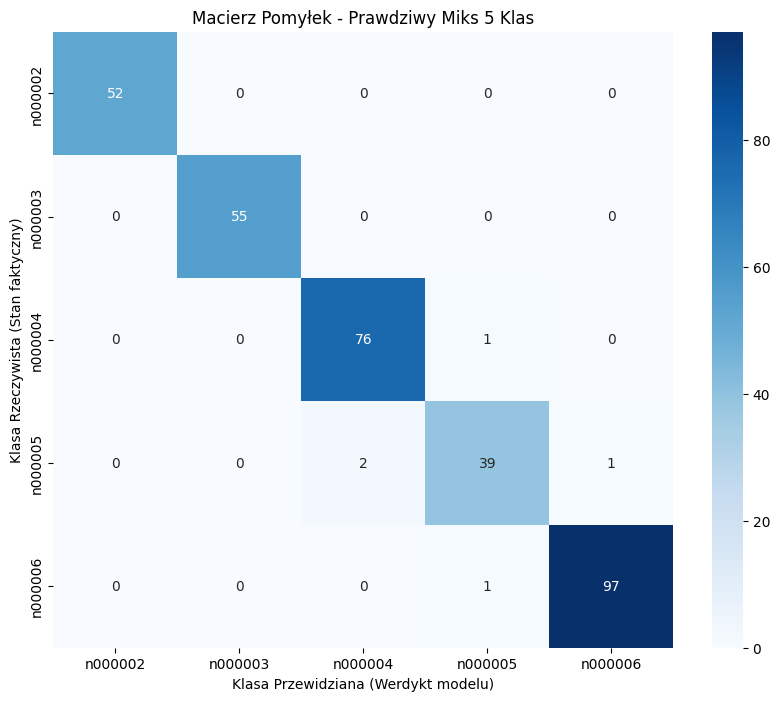


Szczegółowy Raport Klasyfikacji:
              precision    recall  f1-score   support

     n000002       1.00      1.00      1.00        52
     n000003       1.00      1.00      1.00        55
     n000004       0.97      0.99      0.98        77
     n000005       0.95      0.93      0.94        42
     n000006       0.99      0.99      0.99        98

    accuracy                           0.98       324
   macro avg       0.98      0.98      0.98       324
weighted avg       0.98      0.98      0.98       324



In [25]:
# Nazwy osi z Twojej listy z początku kodu
class_names = wybrane_osoby  

# Tworzymy i rysujemy macierz pomyłek
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.ylabel('Klasa Rzeczywista (Stan faktyczny)')
plt.xlabel('Klasa Przewidziana (Werdykt modelu)')
plt.title('Macierz Pomyłek - Prawdziwy Miks 5 Klas')
plt.show()

print("\nSzczegółowy Raport Klasyfikacji:")
print(classification_report(y_true, y_pred, target_names=class_names))

### Dane COCO

In [29]:
import requests
import zipfile
import json

url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
path = 'A:/github/BigDataLabs/Data/annotations_trainval2017.zip'

response = requests.get(url)

with open(path, 'wb') as f:
    f.write(response.content)

# odczytywanie zipa
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall('A:/github/BigDataLabs/Data/')
j_file = 'A:/github/BigDataLabs/Data/annotations/instances_val2017.json'

with open(j_file, 'r') as f:
    x = json.load(f)
print(x.keys())






dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])


In [30]:
print(x['images'][0])

{'license': 4, 'file_name': '000000397133.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000397133.jpg', 'height': 427, 'width': 640, 'date_captured': '2013-11-14 17:02:52', 'flickr_url': 'http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg', 'id': 397133}


In [34]:
filtered_categories = ['person', 'bicycle', 'car', 'dog','cat']
selected_id = []

for var in x['categories']:

    if var['name'] in filtered_categories:
        print(f"Klasa: {var['name']}, ID w bazie COCO: {var['id']}")
        selected_id.append(var['id'])

Klasa: person, ID w bazie COCO: 1
Klasa: bicycle, ID w bazie COCO: 2
Klasa: car, ID w bazie COCO: 3
Klasa: cat, ID w bazie COCO: 17
Klasa: dog, ID w bazie COCO: 18


In [35]:
potrzebne_image_ids = set()


for ann in x['annotations']:
    
    if ann['category_id'] in selected_id:
       
        potrzebne_image_ids.add(ann['image_id'])
        
    
    if len(potrzebne_image_ids) == 1000:
        break

print(f"Zebraliśmy: {len(potrzebne_image_ids)} unikalnych ID zdjęć.")

Zebraliśmy: 1000 unikalnych ID zdjęć.


In [ ]:
import os
import json
import requests


base_dir = "A:/github/BigDataLabs/Data"
json_path = f"{base_dir}/annotations/instances_val2017.json"
output_dir = f"{base_dir}/images"


os.makedirs(output_dir, exist_ok=True)

print("Ładowanie pliku JSON... (to może chwilę potrwać)")
with open(json_path, 'r') as f:
    coco_data = json.load(f)


wybrane_ids = [1, 2, 3, 17, 18]  # person, bicycle, car, cat, dog


potrzebne_image_ids = set()
for ann in coco_data['annotations']:
    if ann['category_id'] in wybrane_ids:
        potrzebne_image_ids.add(ann['image_id'])
    if len(potrzebne_image_ids) == 1000:
        break

print(f"Znaleziono {len(potrzebne_image_ids)} odpowiednich zdjęć. Rozpoczynam pobieranie...")


licznik = 0
for img in coco_data['images']:
    if img['id'] in potrzebne_image_ids:
        file_name = img['file_name']
        url = img['coco_url']
        target_path = f"{output_dir}/{file_name}"
        
        
        if not os.path.exists(target_path):
            try:
                response = requests.get(url, timeout=10)
                if response.status_code == 200:
                    with open(target_path, 'wb') as f:
                        f.write(response.content)
            except Exception as e:
                print(f"Błąd przy pobieraniu {file_name}: {e}")
                continue
        
        licznik += 1
        if licznik % 100 == 0:
            print(f"Pobrano już: {licznik}/1000 zdjęć...")

print(f"Sukces! Wszystkie zdjęcia znajdują się w folderze: {output_dir}")

Ładowanie pliku JSON... (to może chwilę potrwać)
Znaleziono 1000 odpowiednich zdjęć. Rozpoczynam pobieranie...
Pobrano już: 100/1000 zdjęć...
Pobrano już: 200/1000 zdjęć...
Pobrano już: 300/1000 zdjęć...
Pobrano już: 400/1000 zdjęć...
Pobrano już: 500/1000 zdjęć...
Pobrano już: 600/1000 zdjęć...
Pobrano już: 700/1000 zdjęć...
Pobrano już: 800/1000 zdjęć...
Pobrano już: 900/1000 zdjęć...
Pobrano już: 1000/1000 zdjęć...
Sukces! Wszystkie zdjęcia znajdują się w folderze: A:/github/BigDataLabs/Data/images


### Preprocessing


In [ ]:
import numpy as np


# [person, bicycle, car, cat, dog]
id_to_index = {1: 0, 2: 1, 3: 2, 17: 3, 18: 4}


labels_dict = {img_id: np.zeros(5) for img_id in potrzebne_image_ids}


for ann in coco_data['annotations']:
    img_id = ann['image_id']
    cat_id = ann['category_id']
    
  
    if img_id in labels_dict and cat_id in id_to_index:
        index = id_to_index[cat_id]
        labels_dict[img_id][index] = 1.0  

print("Etykiety zostały przygotowane!")

przykładowe_id = list(potrzebne_image_ids)[0]
print(f"ID zdjęcia: {przykładowe_id}, Wektor klas: {labels_dict[przykładowe_id]}")

Etykiety zostały przygotowane!
ID zdjęcia: 458755, Wektor klas: [1. 0. 0. 0. 0.]


### normalizacja danych

In [38]:
from tensorflow.keras.utils import load_img, img_to_array

X = []
y = []

# Przechodzimy po wpisach o obrazach w bazie COCO
for img in coco_data['images']:
    img_id = img['id']
    
    # Interesują nas tylko te zdjęcia, które faktycznie pobraliśmy
    if img_id in potrzebne_image_ids:
        file_name = img['file_name']
        img_path = f"A:/github/BigDataLabs/Data/images/{file_name}"
        
        try:
            # 1. Wczytujemy zdjęcie i od razu skalujemy je do 128x128
            image = load_img(img_path, target_size=(128, 128))
            # 2. Zamieniamy obrazek na macierz liczb (0-255)
            image_array = img_to_array(image) / 255.0  # Normalizacja do przedziału 0-1
            
            # Dodajemy do naszych głównych list
            X.append(image_array)
            y.append(labels_dict[img_id])
        except Exception as e:
            # Na wypadek, gdyby jakieś zdjęcie pobrało się uszkodzone
            print(f"Pominięto plik {file_name}: {e}")

# Zamieniamy listy na końcowe macierze NumPy
X = np.array(X)
y = np.array(y)

print(f"Dane gotowe do sieci!")
print(f"Kształt macierzy zdjęć X: {X.shape}")  # Powinno być (1000, 128, 128, 3)
print(f"Kształt macierzy etykiet y: {y.shape}")  # Powinno być (1000, 5)

Dane gotowe do sieci!
Kształt macierzy zdjęć X: (1000, 128, 128, 3)
Kształt macierzy etykiet y: (1000, 5)


### Tworzymy sieć neuronową

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # 1. Pierwsza warstwa konwolucyjna (wyłapywanie krawędzi i prostych kształtów)
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    
    # 2. Druga warstwa konwolucyjna (bardziej skomplikowane wzorce)
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # 3. Trzecia warstwa konwolucyjna
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Spłaszczenie macierzy 2D do wektora 1D
    Flatten(),
    
    # Warstwa gęsta (klasyfikator) z Dropoutem zapobiegającym przeuczeniu
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    # WARSTWA WYJŚCIOWA - 5 neuronów i sigmoid dla multi-label!
    Dense(5, activation='sigmoid')
])

# Kompilacja modelu
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']  # Mierzy dokładność dla każdej etykiety niezależnie
)

model.summary()

c:\Users\maksp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from sklearn.model_selection import train_test_split

# 1. Dzielimy dane na zestaw treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Odpalamy trenowanie
print("Rozpoczynam trenowanie sieci...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,          # 15 epok na start wystarczy, żeby zobaczyć czy sieć łapie wzorce
    batch_size=32       # podajemy sieci paczki po 32 zdjęcia
)

Rozpoczynam trenowanie sieci...
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - binary_accuracy: 0.7915 - loss: 0.4903 - val_binary_accuracy: 0.8040 - val_loss: 0.4674
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - binary_accuracy: 0.8027 - loss: 0.4604 - val_binary_accuracy: 0.8040 - val_loss: 0.4675
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - binary_accuracy: 0.8093 - loss: 0.4446 - val_binary_accuracy: 0.8040 - val_loss: 0.4542
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - binary_accuracy: 0.8098 - loss: 0.4308 - val_binary_accuracy: 0.8020 - val_loss: 0.4374
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - binary_accuracy: 0.8175 - loss: 0.4196 - val_binary_accuracy: 0.8070 - val_loss: 0.4462
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - binary_accuracy: 0.8232 - loss: 0.4072 - val_binary_accuracy: 0.8010 - val_loss: 0.4276
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - binary_accuracy: 0.8308 - loss: 0.3741 - val_binary_accuracy: 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


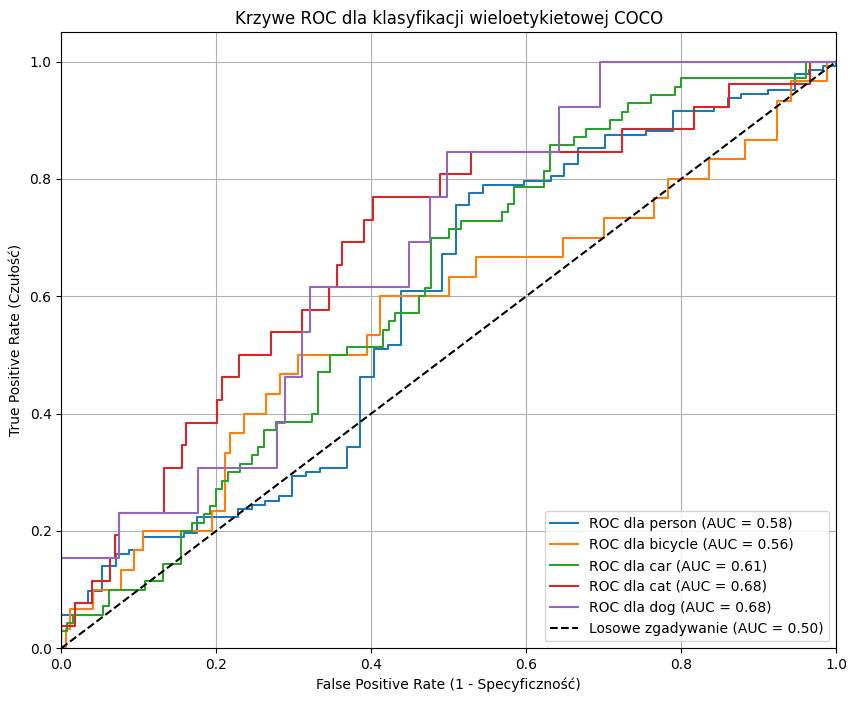

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Model generuje prawdopodobieństwa dla danych testowych
y_pred = model.predict(X_test)

# Nazwy klas w odpowiedniej kolejności indeksów (0 do 4)
klasy = ['person', 'bicycle', 'car', 'cat', 'dog']

plt.figure(figsize=(10, 8))

# 2. Liczymy ROC i AUC dla każdej klasy osobno w pętli
for i in range(len(klasy)):
    # y_test[:, i] to faktyczne wartości (0 lub 1) dla i-tej klasy
    # y_pred[:, i] to przewidziane prawdopodobieństwa dla i-tej klasy
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Rysujemy linię ROC dla danej klasy
    plt.plot(fpr, tpr, label=f'ROC dla {klasy[i]} (AUC = {roc_auc:.2f})')

# Rysujemy linię losowego zgadywania (diagonalną)
plt.plot([0, 1], [0, 1], 'k--', label='Losowe zgadywanie (AUC = 0.50)')

# Estetyka wykresu
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specyficzność)')
plt.ylabel('True Positive Rate (Czułość)')
plt.title('Krzywe ROC dla klasyfikacji wieloetykietowej COCO')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### CamVid - Londyn

In [3]:
import os

cam_vid_dir = "A:/github/BigDataLabs/Data/CamVid"

image_dir = os.path.join(cam_vid_dir, 'train')
mask_dir = os.path.join(cam_vid_dir, 'train_labels')


images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))

# 3. Sprawdźmy, ile mamy plików i jak wyglądają pierwsze z brzegu
print(f"Liczba zdjęć treningowych: {len(images)}")
print(f"Liczba masek treningowych: {len(masks)}")

print("\nPierwsze 3 pary plików:")
for i in range(3):
    print(f"Zdjęcie: {images[i]}  <--->  Maska: {masks[i]}")



Liczba zdjęć treningowych: 369
Liczba masek treningowych: 369

Pierwsze 3 pary plików:
Zdjęcie: 0001TP_009210.png  <--->  Maska: 0001TP_009210_L.png
Zdjęcie: 0001TP_009240.png  <--->  Maska: 0001TP_009240_L.png
Zdjęcie: 0001TP_009390.png  <--->  Maska: 0001TP_009390_L.png


In [9]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

X_train = []
y_train = []

for i in range(100):

    img_path = os.path.join(image_dir, images[i])
    mask_path = os.path.join(mask_dir, masks[i])

    # ladujemy x data set jakies zwykle zdjecia
    img = load_img(img_path, target_size = (128, 128))
    img_array = img_to_array(img) / 255.0
    X_train.append(img_array)

    # ladujemy maski
    mask = load_img(mask_path, target_size = (128, 128))
    mask_array = img_to_array(mask).astype('uint8') 
    y_train.append(mask_array)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"Mamy pełny dostęp do danych pikseli!")
print(f"Wymiary macierzy zdjęć X_train: {X_train.shape}")
print(f"Wymiary macierzy masek y_train: {y_train.shape}")


Mamy pełny dostęp do danych pikseli!
Wymiary macierzy zdjęć X_train: (100, 128, 128, 3)
Wymiary macierzy masek y_train: (100, 128, 128, 3)


In [ ]:
# Ścieżki do folderów testowych
test_imgs_dir = "A:/github/BigDataLabs/Data/CamVid/test"
test_masks_dir = "A:/github/BigDataLabs/Data/CamVid/test_labels"


test_images_names = sorted(os.listdir(test_imgs_dir))
test_masks_names = sorted(os.listdir(test_masks_dir))

X_test = []
y_test = []


for i in range(100):
    img_path = os.path.join(test_imgs_dir, test_images_names[i])
    mask_path = os.path.join(test_masks_dir, test_masks_names[i])
    
    
    img = load_img(img_path, target_size=(128, 128))
    X_test.append(img_to_array(img) / 255.0)
    
    
    mask = load_img(mask_path, target_size=(128, 128))
    y_test.append(img_to_array(mask))


X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Dane testowe gotowe!")
print(f"Wymiary macierzy zdjęć X_test: {X_test.shape}")  # Powinno być (50, 128, 128, 3)
print(f"Wymiary macierzy masek y_test: {y_test.shape}")  # Powinno być (50, 128, 128, 1)

Dane testowe gotowe!
Wymiary macierzy zdjęć X_test: (100, 128, 128, 3)
Wymiary macierzy masek y_test: (100, 128, 128, 3)


### Redukcja klas 

In [ ]:
def rgb_to_2d_label(mask_array):
    return (mask_array[:,:,0] * 1000000 + mask_array[:,:,1] * 1000 + mask_array[:,:, 2] )

y_train_flat = np.array([rgb_to_2d_label(m.astype(int)) for m in y_train])
y_test_flat = np.array([rgb_to_2d_label(m.astype(int)) for m in y_test])

unique_colors = np.unique(y_train_flat)
mapping ={color : i for i, color in enumerate(unique_colors)}


y_train_index = np.vectorize(mapping.get)(y_train_flat)
y_test_index = np.vectorize(mapping.get)(y_test_flat)

print(f'liczba klas {len(unique_colors)}')



liczba klas 30


In [13]:
from tensorflow.keras.utils import to_categorical

LICZBA_KLAS = len(unique_colors)


y_train_categorical = to_categorical(y_train_index, num_classes=LICZBA_KLAS)
y_test_categorical = to_categorical(y_test_index, num_classes=LICZBA_KLAS)

print(f"Ostateczny kształt masek treningowych: {y_train_categorical.shape}")
print(f"Ostateczny kształt masek testowych: {y_test_categorical.shape}")

Ostateczny kształt masek treningowych: (100, 128, 128, 30)
Ostateczny kształt masek testowych: (100, 128, 128, 30)


### Nueral network implementation

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_unet(input_shape = (128,128,3), num_classes = 30):
    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same' )(inputs)
    c1 = layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same' )(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same')(p1)
    c2 = layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(128, (3,3), activation = 'relu', padding = 'same')(p2)
    c3 = layers.Conv2D(128, (3,3), activation = 'relu', padding = 'same')(c3)

    u4 = layers.Conv2DTranspose(64, (2,2), strides = (2,2), padding = 'same')(c3) # 64x64
    u4 = layers.concatenate([u4,c2])
    c4 = layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same')(u4)
    c4 = layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same')(c4)

    u5 = layers.Conv2DTranspose(32, (2,2), strides = (2,2), padding = 'same')(c4) # 128x128
    u4 = layers.concatenate([u5,c1])
    c5 = layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same')(u5)
    c5 = layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same')(c5)

    outputs = layers.Conv2D(num_classes, (1,1), activation = 'softmax')(c5)

    model = models.Model(inputs = [inputs], outputs = [outputs])

    return model

model = build_unet(input_shape = (128, 128, 3), num_classes = LICZBA_KLAS)

# trzeba skompilować model

model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
model.summary()








Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_33[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64,    │          0 │ conv2d_34[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_35[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 32,    │          0 │ conv2d_36[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_37[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 64, 64,    │     32,832 │ conv2d_38[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 64, 64,    │     73,792 │ concatenate_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_39[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 128, 128,  │      8,224 │ conv2d_40[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 128, 128,  │     18,496 │ conv2d_transpose… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_41[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 128, 128,  │      1,950 │ conv2d_42[0][0] 

 Total params: 496,158 (1.89 MB)

 Trainable params: 496,158 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train, y_train_categorical,
    validation_data=(X_test, y_test_categorical),
    epochs=10,         # Na start dajemy 10 epok, żeby zobaczyć, czy ruszy
    batch_size=8       # Małe paczki, żeby oszczędzać RAM komputera
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 473ms/step - accuracy: 0.2197 - loss: 2.7559 - val_accuracy: 0.2321 - val_loss: 2.4606
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 432ms/step - accuracy: 0.2777 - loss: 2.2119 - val_accuracy: 0.3389 - val_loss: 2.2709
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.3056 - loss: 2.0574 - val_accuracy: 0.3382 - val_loss: 2.1766
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 435ms/step - accuracy: 0.3579 - loss: 1.9052 - val_accuracy: 0.3472 - val_loss: 2.0149
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 437ms/step - accuracy: 0.4296 - loss: 1.7827 - val_accuracy: 0.3717 - val_loss: 1.9546
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 426ms/step - accuracy: 0.4907 - loss: 1.6948 - val_accuracy: 0.4341 - val_loss: 1.8756
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 439ms/step - accuracy: 0.5730 - loss: 1.5432 - val_accuracy: 0.4530 - val_loss: 1.8331
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 441ms/step - accuracy: 0.5869 - loss: 1.4632 - val_accuracy: 0.

In [ ]:
import numpy as np
import tensorflow as tf

print("\n--- Ewaluacja modelu przy użyciu miary IoU ---")


y_pred = model.predict(X_test)


y_pred_argmax = np.argmax(y_pred, axis=-1)
y_test_argmax = np.argmax(y_test_categorical, axis=-1)


iou_metric = tf.keras.metrics.MeanIoU(num_classes=LICZBA_KLAS)
iou_metric.update_state(y_test_argmax, y_pred_argmax)

# 4. Wyświetlamy wynik
print(f"Średni IoU (Mean IoU) na zbiorze testowym: {iou_metric.result().numpy():.4f}")


--- Ewaluacja modelu przy użyciu miary IoU ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step
Średni IoU (Mean IoU) na zbiorze testowym: 0.0848


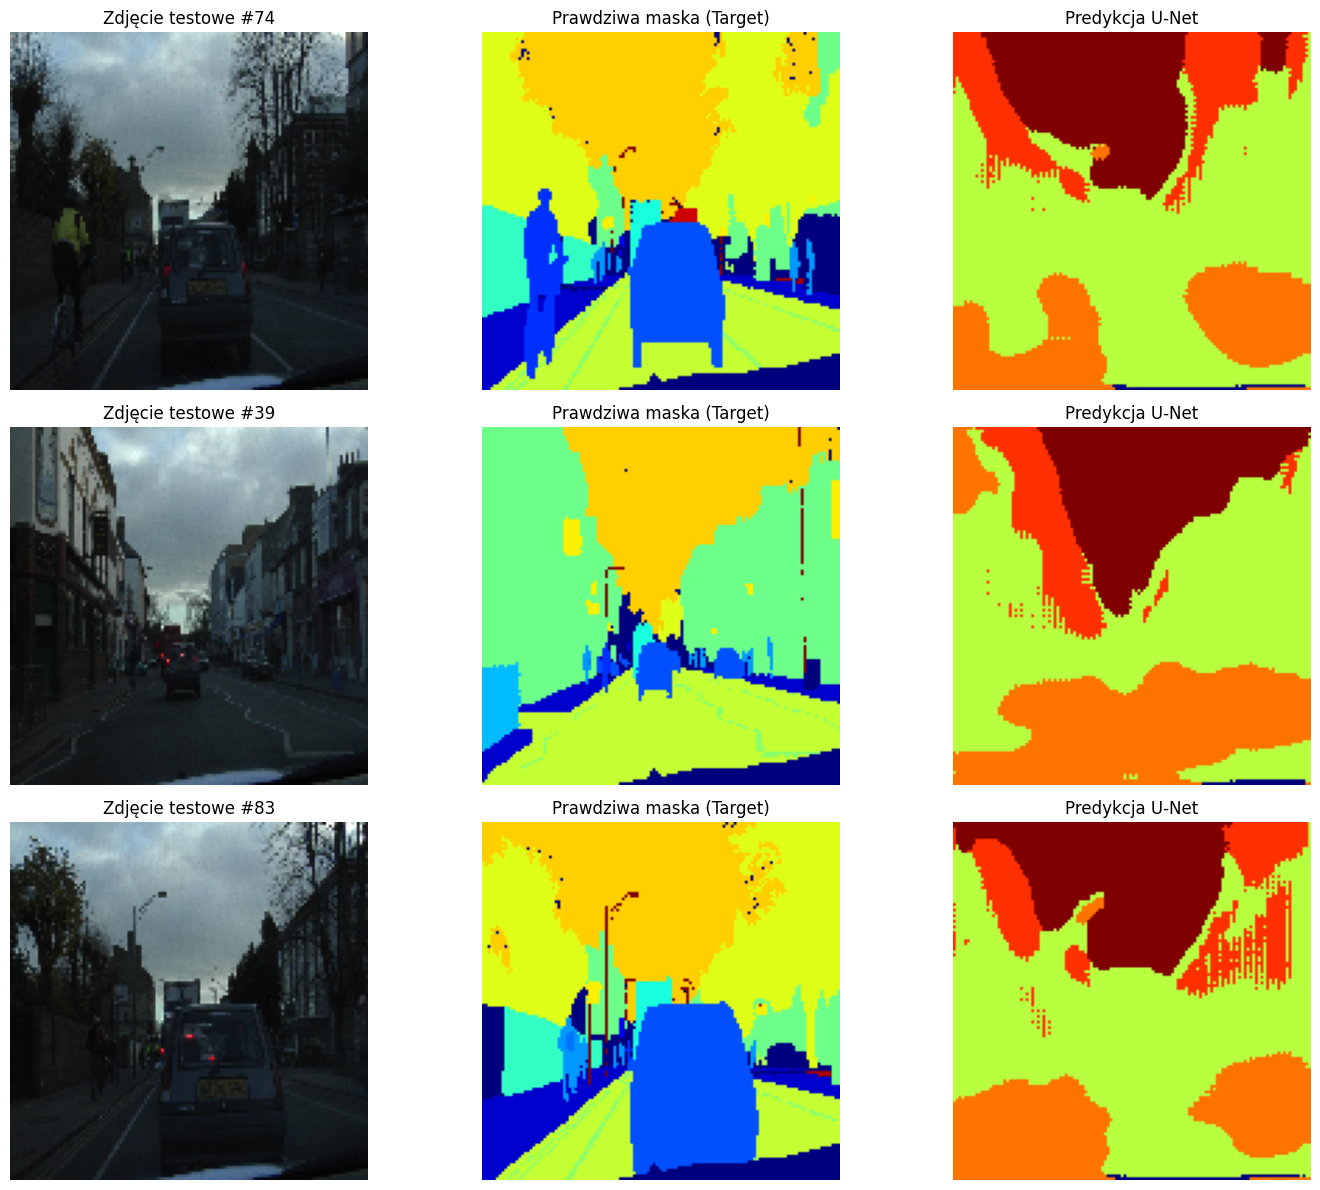

In [ ]:
import matplotlib.pyplot as plt
import random


sample_indices = random.sample(range(len(X_test)), 3)


plt.figure(figsize=(15, 12))

for i, idx in enumerate(sample_indices):
    
    plt.subplot(3, 3, i * 3 + 1)
    plt.imshow(X_test[idx])
    plt.title(f"Zdjęcie testowe #{idx}")
    plt.axis('off')
    
    
    plt.subplot(3, 3, i * 3 + 2)
    plt.imshow(y_test_argmax[idx], cmap='jet')
    plt.title("Prawdziwa maska (Target)")
    plt.axis('off')
    
    
    plt.subplot(3, 3, i * 3 + 3)
    plt.imshow(y_pred_argmax[idx], cmap='jet')
    plt.title("Predykcja U-Net")
    plt.axis('off')

plt.tight_layout()
plt.show()